In [2]:
import bilby
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("../MATPLOTLIB_RCPARAMS.sty")

In [2]:
posterior_NRSur7dq4_incl_pi_2 = bilby.result.Result.from_json(
    'run2/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off_incl_pi_2 = bilby.result.Result.from_json(
    'run2/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
) 

for r in [
    posterior_NRSur7dq4_incl_pi_2,
    posterior_NRSur7dq4_subdom_off_incl_pi_2,
]:
    r.outdir = "run2/subdom_off/outdir/result"

posterior_NRSur7dq4_incl_pi_3 = bilby.result.Result.from_json(
    'run3/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off_incl_pi_3 = bilby.result.Result.from_json(
    'run3/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
) 

for r in [
    posterior_NRSur7dq4_incl_pi_3,
    posterior_NRSur7dq4_subdom_off_incl_pi_3,
]:
    r.outdir = "run3/subdom_off/outdir/result" 

posterior_NRSur7dq4_incl_0 = bilby.result.Result.from_json(
    'run4/NRSur/outdir/final_result/NRSur_data0_10-0_analysis_ET_result.json'
)

posterior_NRSur7dq4_subdom_off_incl_0 = bilby.result.Result.from_json(
    'run4/subdom_off/outdir/final_result/subdom_off_data0_10-0_analysis_ET_result.json'
) 

for r in [
    posterior_NRSur7dq4_incl_0,
    posterior_NRSur7dq4_subdom_off_incl_0,
]:
    r.outdir = "run4/subdom_off/outdir/result" 

In [3]:
truths = posterior_NRSur7dq4_incl_pi_2.injection_parameters

truths

{'total_mass': 90.0,
 'mass_ratio': 1.0,
 'a_1': 0.8,
 'a_2': 0.8,
 'tilt_1': 1.5707963267948966,
 'tilt_2': 1.5707963267948966,
 'phi_12': 3.141592653589793,
 'phi_jl': 0.0,
 'luminosity_distance': 500.0,
 'dec': 0.761,
 'ra': 1.94,
 'theta_jn': 1.5707963267948966,
 'psi': 0.0,
 'phase': 0.0,
 'geocent_time': 10.0,
 'reference_frequency': 20.0,
 'waveform_approximant': 'NRSur7dq4',
 'minimum_frequency': 20,
 'mass_1': 45.0,
 'mass_2': 45.0,
 'chirp_mass': 39.17477534832557,
 'symmetric_mass_ratio': 0.25,
 'iota': array(1.57079633),
 'spin_1x': array(-1.46957616e-16),
 'spin_1y': array(0.8),
 'spin_1z': array(4.8985872e-17),
 'spin_2x': array(4.8985872e-17),
 'spin_2y': array(-0.8),
 'spin_2z': array(4.8985872e-17),
 'phi_1': 1.5707963267948966,
 'phi_2': 4.71238898038469,
 'chi_eff': 4.898587196589413e-17,
 'chi_1_in_plane': 0.8,
 'chi_2_in_plane': 0.8,
 'chi_p': 0.8,
 'cos_tilt_1': 6.123233995736766e-17,
 'cos_tilt_2': 6.123233995736766e-17,
 'redshift': 0.10485144638260473,
 'comovi

/home/jannik/miniconda3/envs/bilby/lib/python3.10/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


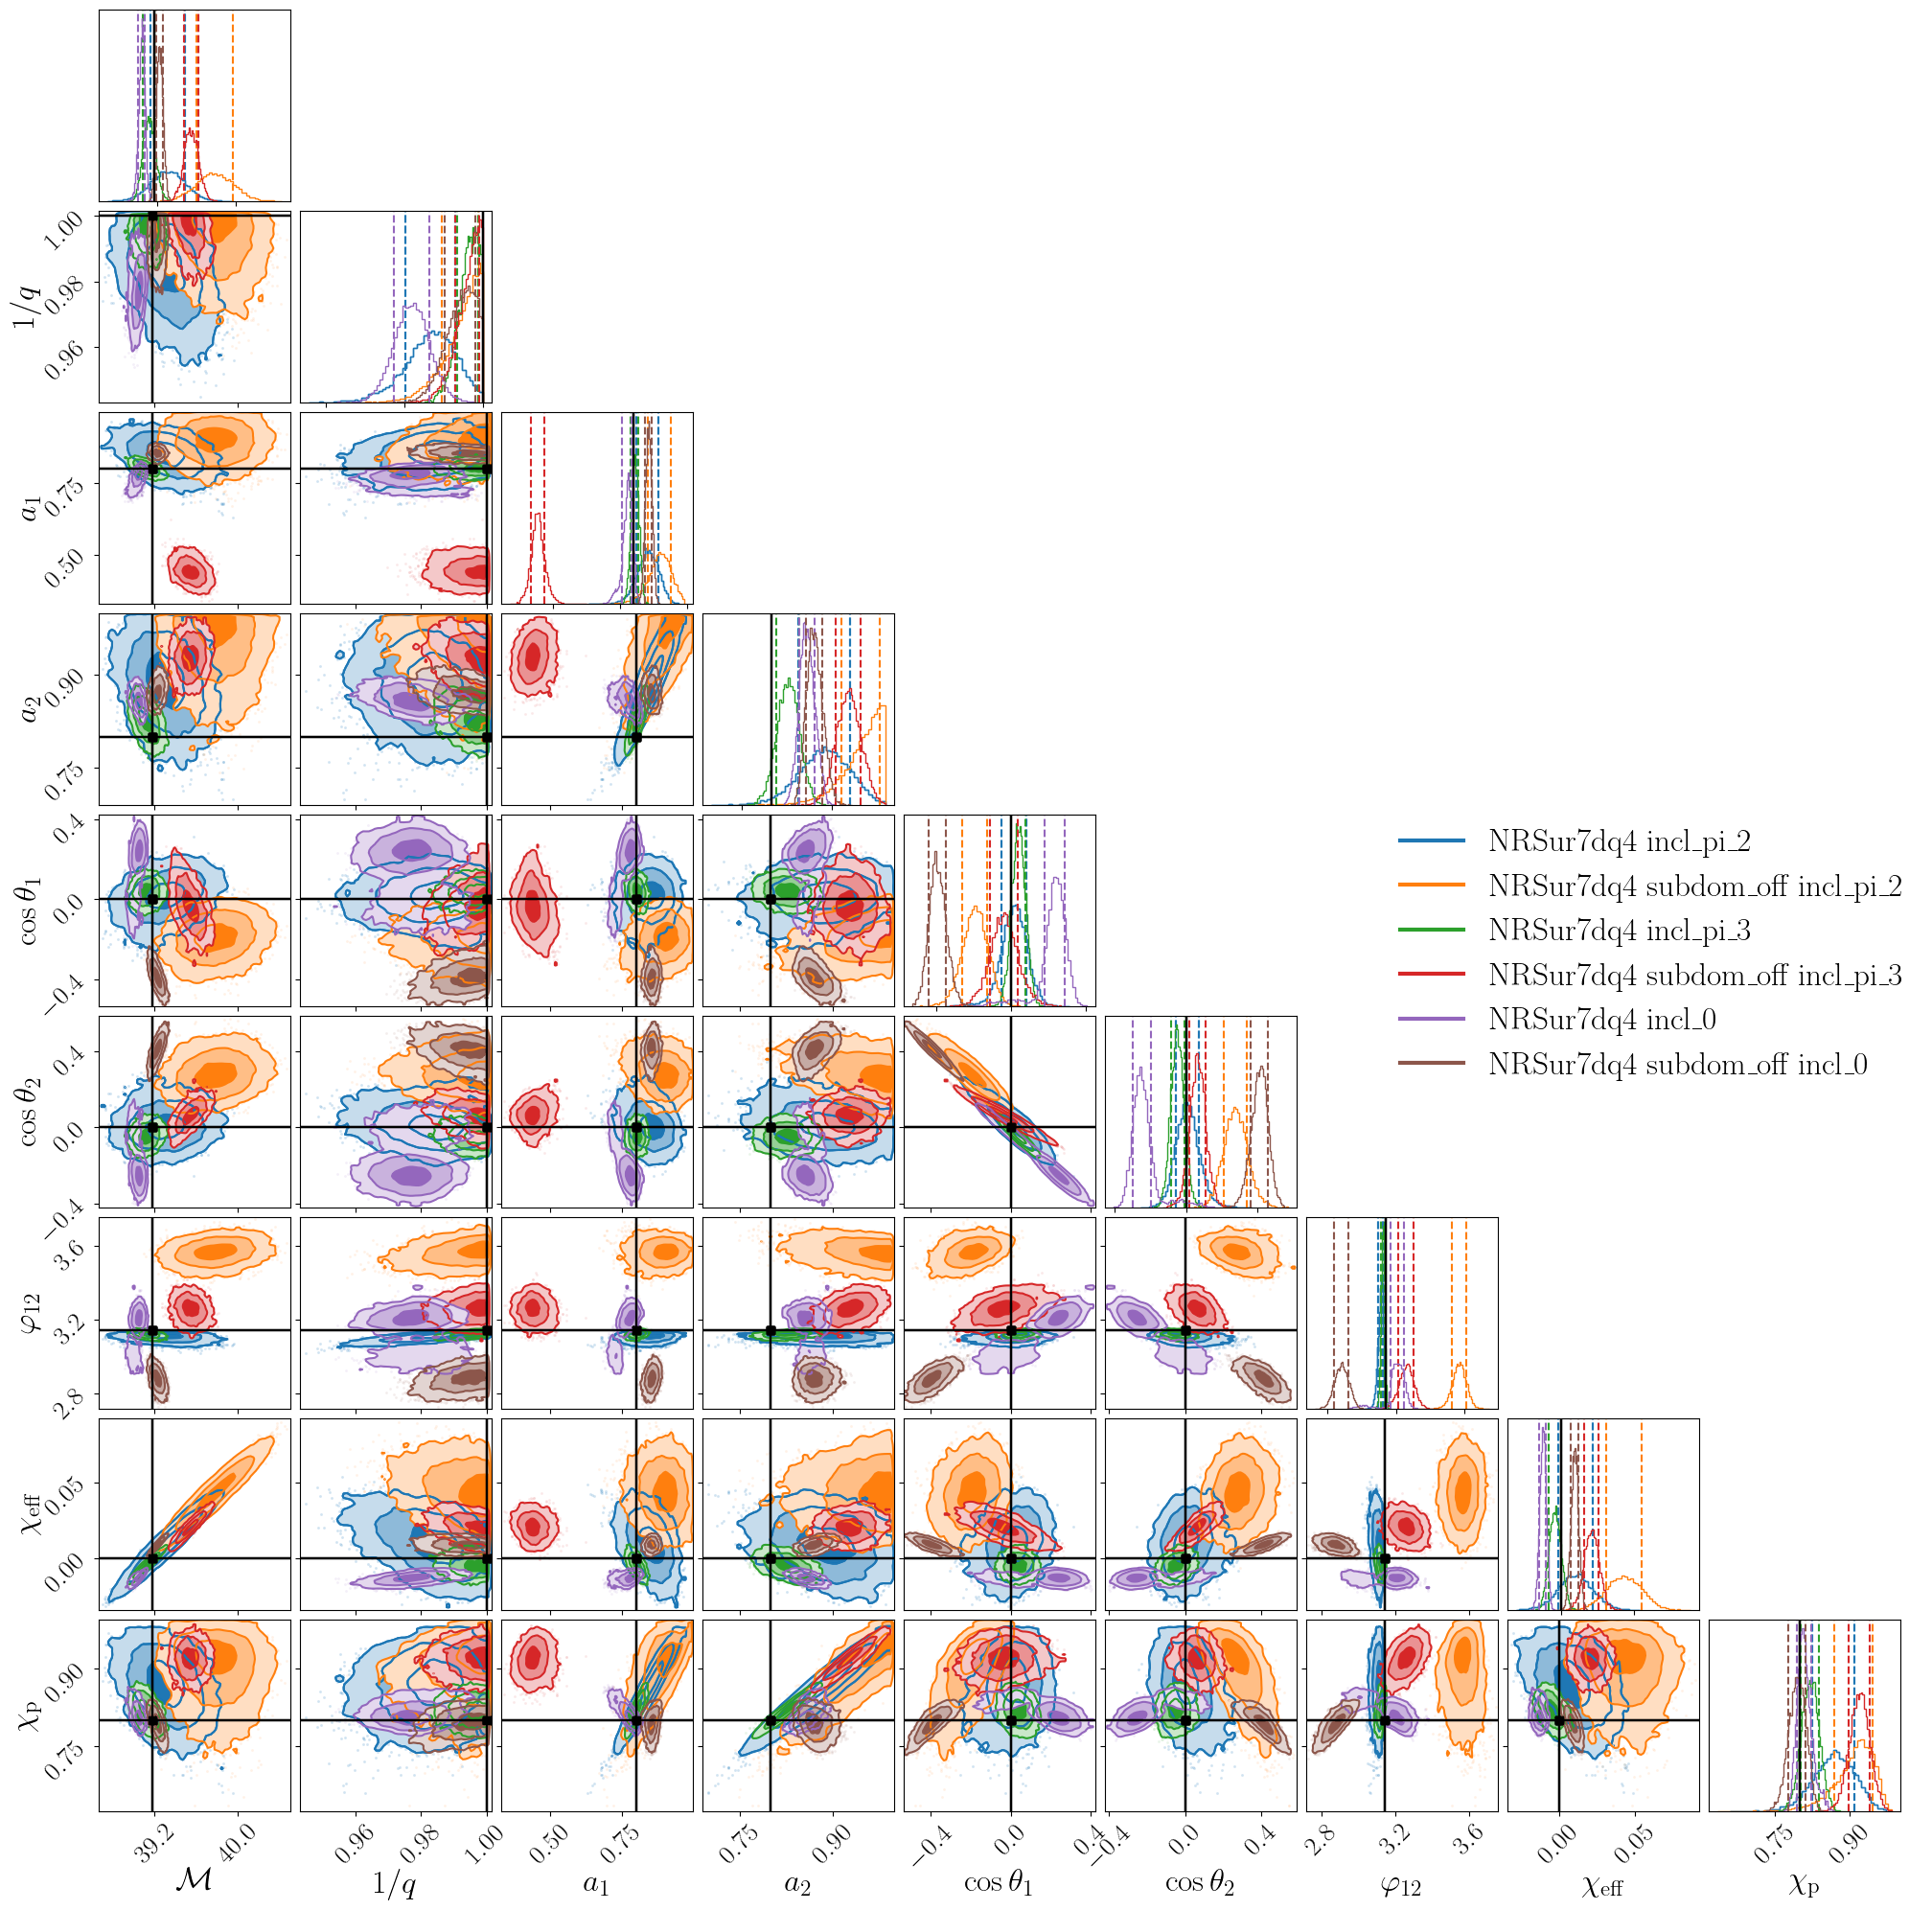

In [4]:
fig = bilby.result.plot_multiple(
    [
        posterior_NRSur7dq4_incl_pi_2,
        posterior_NRSur7dq4_subdom_off_incl_pi_2, 
        posterior_NRSur7dq4_incl_pi_3,
        posterior_NRSur7dq4_subdom_off_incl_pi_3,
        posterior_NRSur7dq4_incl_0,
        posterior_NRSur7dq4_subdom_off_incl_0,
    ],
    filename=None, 
    parameters={
        'chirp_mass': truths['chirp_mass'],
        'mass_ratio': truths['mass_ratio'],
        'a_1': truths['a_1'],
        'a_2': truths['a_2'],
        'cos_tilt_1': np.cos(truths['tilt_1']),
        'cos_tilt_2': np.cos(truths['tilt_2']),
        'phi_12': truths['phi_12'],
        'chi_eff': truths['chi_eff'],
        'chi_p': truths['chi_p']
    },
    corner_labels=[r'$\mathcal{M}$', 
            r'$1/q$', 
            r'$a_1$', 
            r'$a_2$', 
            r'$\cos\theta_1$', 
            r'$\cos\theta_2$', 
            r'$\varphi_{12}$', 
            r'$\chi_{\text{eff}}$', 
            r'$\chi_{\text{p}}$'
            ],
    labels=[],
    colors=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown'],
    smooth=True,
    title_kwargs=dict(fontsize=24, y=1.05),
    label_kwargs=dict(fontsize=24),
    truth_color='black'
)

# tick font size
for ax in fig.axes:
    ax.tick_params(labelsize=20)

# remove all legends on all axes (Bilby's ghost box lives here)
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove() 

# remove all titles on all axes
for ax in fig.axes:
    ax.set_title("")

# my new legend
handles = [
    Line2D([], [], color='tab:blue', lw=3, label='NRSur7dq4 incl_pi_2'),
    Line2D([], [], color='tab:orange', lw=3, label='NRSur7dq4 subdom_off incl_pi_2'),
    Line2D([], [], color='tab:green', lw=3, label='NRSur7dq4 incl_pi_3'),
    Line2D([], [], color='tab:red', lw=3, label='NRSur7dq4 subdom_off incl_pi_3'),
    Line2D([], [], color='tab:purple', lw=3, label='NRSur7dq4 incl_0'),
    Line2D([], [], color='tab:brown', lw=3, label='NRSur7dq4 subdom_off incl_0')]
fig.legend(
    handles=handles,
    fontsize=24,
    loc='center right',
    frameon=False)

# fig.savefig('corner_incl.pdf', bbox_inches='tight')
plt.show()


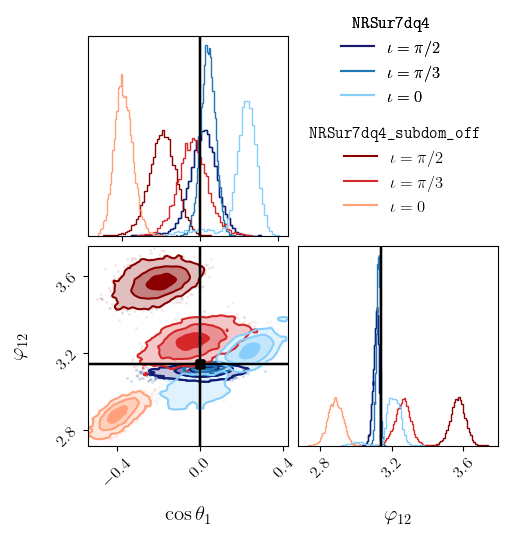

In [22]:
fig = bilby.result.plot_multiple(
    [
        posterior_NRSur7dq4_incl_pi_2,
        posterior_NRSur7dq4_subdom_off_incl_pi_2, 
        posterior_NRSur7dq4_incl_pi_3,
        posterior_NRSur7dq4_subdom_off_incl_pi_3,
        posterior_NRSur7dq4_incl_0,
        posterior_NRSur7dq4_subdom_off_incl_0,
    ],
    filename=None, 
    parameters={
        'cos_tilt_1': np.cos(truths['tilt_1']),
        'phi_12': truths['phi_12'],
    },
    corner_labels=[
            r'$\cos\theta_1$', 
            r'$\varphi_{12}$', 
            ],
    labels=[],
colours = [
    'midnightblue',   # NRSur, pi/2  (sehr dunkel)
    'darkred',        # subdom_off, pi/2 (sehr dunkel)
    'tab:blue',       # NRSur, pi/3  (Referenz / Mitte)
    'tab:red',        # subdom_off, pi/3 (Referenz / Mitte)
    'lightskyblue',   # NRSur, 0     (sehr hell)
    'lightsalmon',      # subdom_off, 0 (sehr hell)
],
    smooth=True,
    title_kwargs=dict(fontsize=15),
    label_kwargs=dict(fontsize=15),
    truth_color='black', 
    quantiles=None
)

# tick font size
for ax in fig.axes:
    ax.tick_params(labelsize=12)

# remove all legends on all axes (Bilby's ghost box lives here)
for ax in fig.axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove() 

# remove all titles on all axes
for ax in fig.axes:
    ax.set_title("")

# my new legend
model_handles = [
    Line2D([], [], color='midnightblue', label=r'$\iota=\pi/2$'),
    Line2D([], [], color='tab:blue', label=r'$\iota=\pi/3$'),
    Line2D([], [], color='lightskyblue', label=r'$\iota=0$'),
]

incl_handles = [
    Line2D([], [], color='darkred', label=r'$\iota=\pi/2$'),
    Line2D([], [], color='tab:red', label=r'$\iota=\pi/3$'),
    Line2D([], [], color='lightsalmon', label=r'$\iota=0$'),
]


leg1 = fig.legend(
    handles=model_handles,
    loc='upper right',
    bbox_to_anchor=(0.85, .99),
    frameon=False,
    fontsize=12,
    title=r'\texttt{NRSur7dq4}',
    title_fontsize=12,
)

leg2 = fig.legend(
    handles=incl_handles,
    loc='upper right',
    bbox_to_anchor=(0.92, 0.79),
    frameon=False,
    fontsize=12,
    title=r'\texttt{NRSur7dq4\_subdom\_off}',
    title_fontsize=12,
)

fig.add_artist(leg1)


fig.savefig('inclination_dependence.pdf', bbox_inches='tight')
plt.show()
